In [1]:
# Import the necessary Python modules.

# Data Management/Investigation
import pandas as pd
from pandas.api.types import CategoricalDtype # Ordering categories
import numpy as np
import missingno as miss

# Plotting libraries
from plotnine import *
import matplotlib.pyplot as plt

# For pre-processing data 
from sklearn import preprocessing as pp 
from sklearn.compose import ColumnTransformer 

# For splits and CV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold # Cross validation 
from sklearn.model_selection import cross_validate # Cross validation 
from sklearn.model_selection import GridSearchCV # Cross validation + param. tuning.

# Machine learning methods
from sklearn.linear_model import LinearRegression as LM
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.tree import DecisionTreeRegressor as DT
from sklearn import tree # For plotting the decision tree rules
from sklearn.ensemble import BaggingRegressor as Bag
from sklearn.ensemble import RandomForestRegressor as RF

# For evaluating our model's performance
import sklearn.metrics as m

# Pipeline to combine modeling elements
from sklearn.pipeline import Pipeline

# For model interpretation
from sklearn.inspection import (
    permutation_importance,
    partial_dependence, 
    PartialDependenceDisplay, 
    plot_partial_dependence
)

# Misc
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the data on Hospital Pricing.
pricing_data = pd.read_csv("../data/Hospital_Data/Final_Pricing.csv")

# Remove the first column.
pricing_data = pricing_data.iloc[:, 1:]

# Remove the Hospital Name column.
pricing_data = pricing_data.drop(columns = ["HospitalName"])

In [3]:
# View the data types of the Pricing data.
pricing_data.dtypes

HospitalPrice_70450    float64
ZipCode                  int64
MedIncome               object
MeanIncome              object
dtype: object

In [4]:
# Convert ZipCode to string.
pricing_data["ZipCode"] = pricing_data["ZipCode"].astype(str)

# Convert MedIncome and MeanIncome to float64.
pricing_data["MedIncome"] = pd.to_numeric(pricing_data.MedIncome, errors = "coerce")
pricing_data["MeanIncome"] = pd.to_numeric(pricing_data.MeanIncome, errors = "coerce")

In [5]:
pricing_data.dtypes

HospitalPrice_70450    float64
ZipCode                 object
MedIncome              float64
MeanIncome             float64
dtype: object

In [6]:
# Convert categorical variables to categories.
for column in ["ZipCode"]:
    pricing_data[column] = pricing_data[column].astype("category")

<AxesSubplot:>

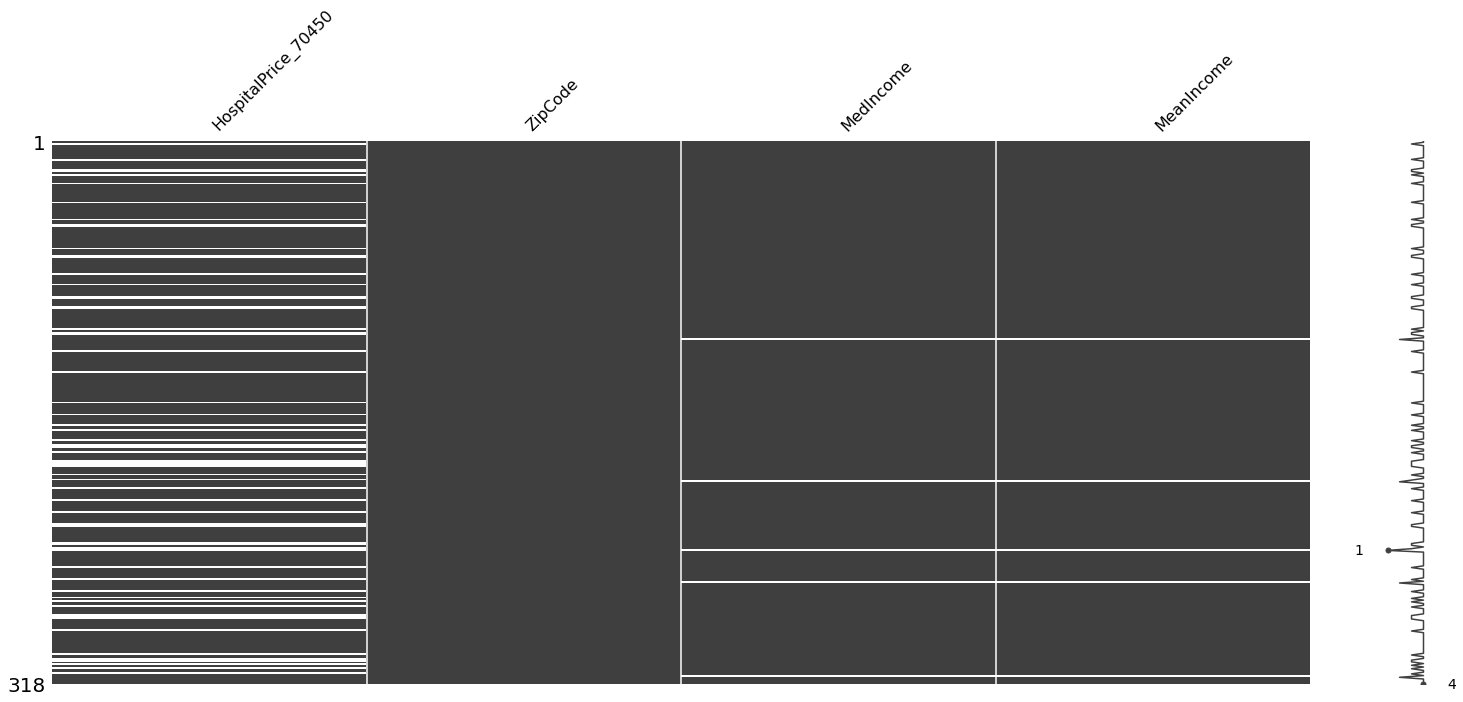

In [7]:
# We now check for missingness in the data.
miss.matrix(pricing_data) # Missing data for HospitalPrice_70450, Median Income, and Mean Income.

In [8]:
# Split the data into a training and test dataset.
# Identify the hospital's pricing for 70450 as the dependent variable.
y = pricing_data[["HospitalPrice_70450"]]
# Identify the other variables as the independent variables.
X = pricing_data.drop(columns = ["HospitalPrice_70450"])
# Split the data with 75% of the data into the training data and holding 25% of the data as a test set.
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = .25, random_state = 202112)

# Ensure the training and test data have been split properly.
print("Percent of Data that is Training Data:", train_X.shape[0] / pricing_data.shape[0])
print("Percent of Data that is Test Data:", test_X.shape[0] / pricing_data.shape[0])

Percent of Data that is Training Data: 0.7484276729559748
Percent of Data that is Test Data: 0.25157232704402516


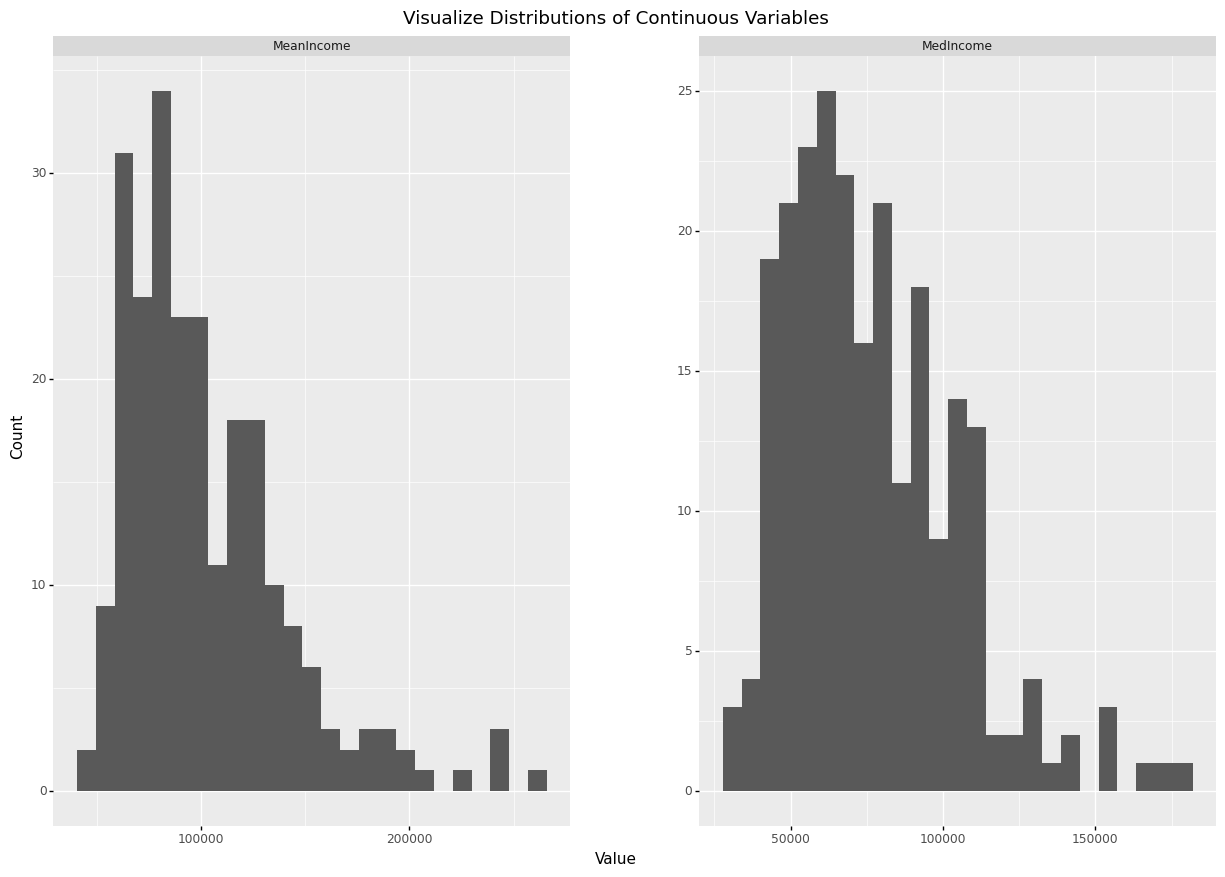

<ggplot: (8787537264631)>

In [9]:
# We explore the training data.
# Plot the continuous variables to observe their distributions.

# Identify the continuous variables (int and float).
d = train_X.select_dtypes(include = ["int", "float"]).melt()

# Plot the continous variables.
(
    ggplot(d, aes(x = "value")) +
    geom_histogram(bins = 25) +
    facet_wrap("variable", scales = "free") +
    theme(figure_size = (15, 10),
          subplots_adjust = {"wspace" : 0.25, "hspace" : 0.25}) +
    labs(x = "Value", y = "Count", title = "Visualize Distributions of Continuous Variables")
)

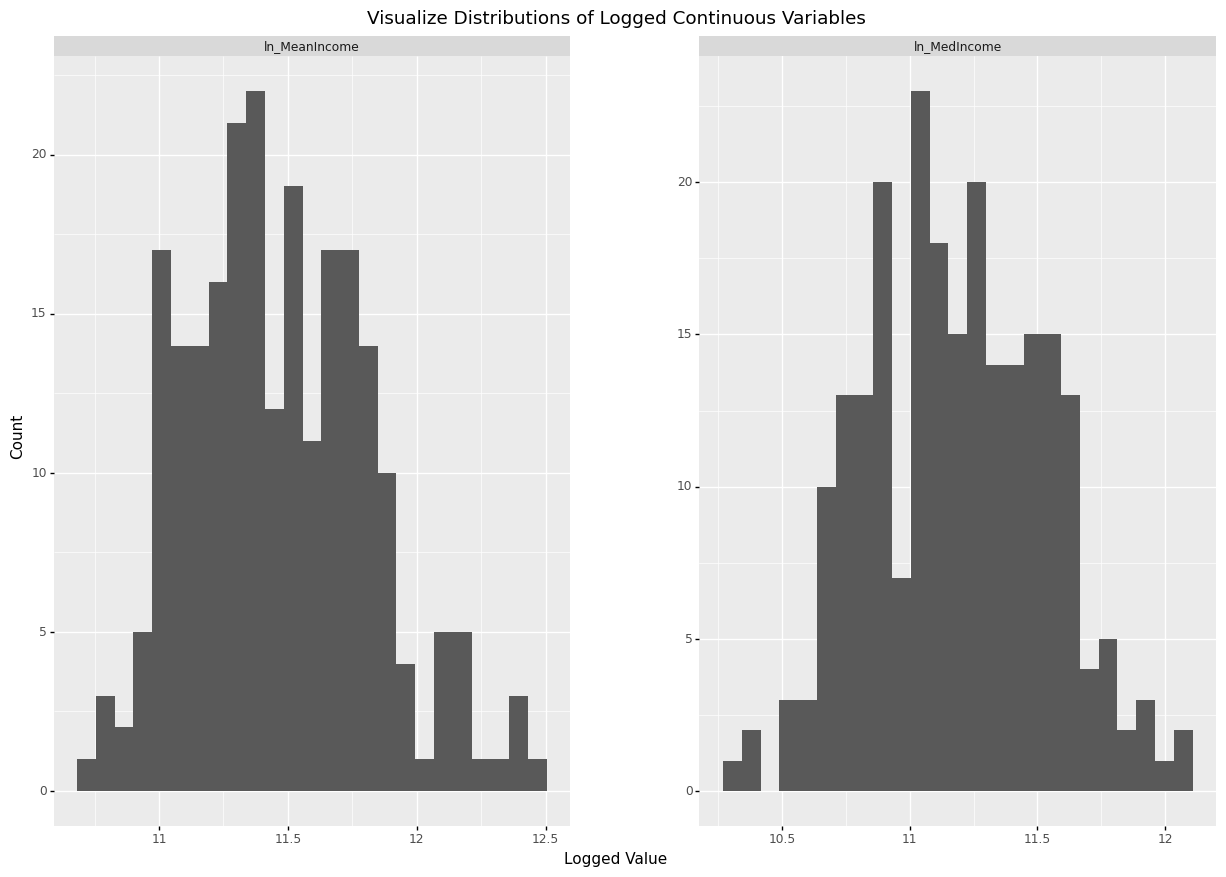

<ggplot: (8787487858170)>

In [10]:
# Take a copy of the training data.
d = train_X.copy()

# Log transform *MedIncome*.
d["ln_MedIncome"] =  np.log(d["MedIncome"] + 1)

# Log transform *MeanIncome*.
d["ln_MeanIncome"] =  np.log(d["MeanIncome"] + 1)

# We observe the logged continuous variables to ensure we have transformed them properly.

# Identify the logged continuous variables.
d_ln = d.loc[:, d.columns.str.startswith("ln_")].melt()

# Plot the logged continuous variables.
(
    ggplot(d_ln, aes(x = "value")) +
    geom_histogram(bins = 25) +
    facet_wrap("variable", scales = "free") +
    theme(figure_size = (15, 10),
          subplots_adjust = {"wspace" : 0.25, "hspace" : 0.25}) +
    labs(x = "Logged Value", y = "Count", title = "Visualize Distributions of Logged Continuous Variables")
)

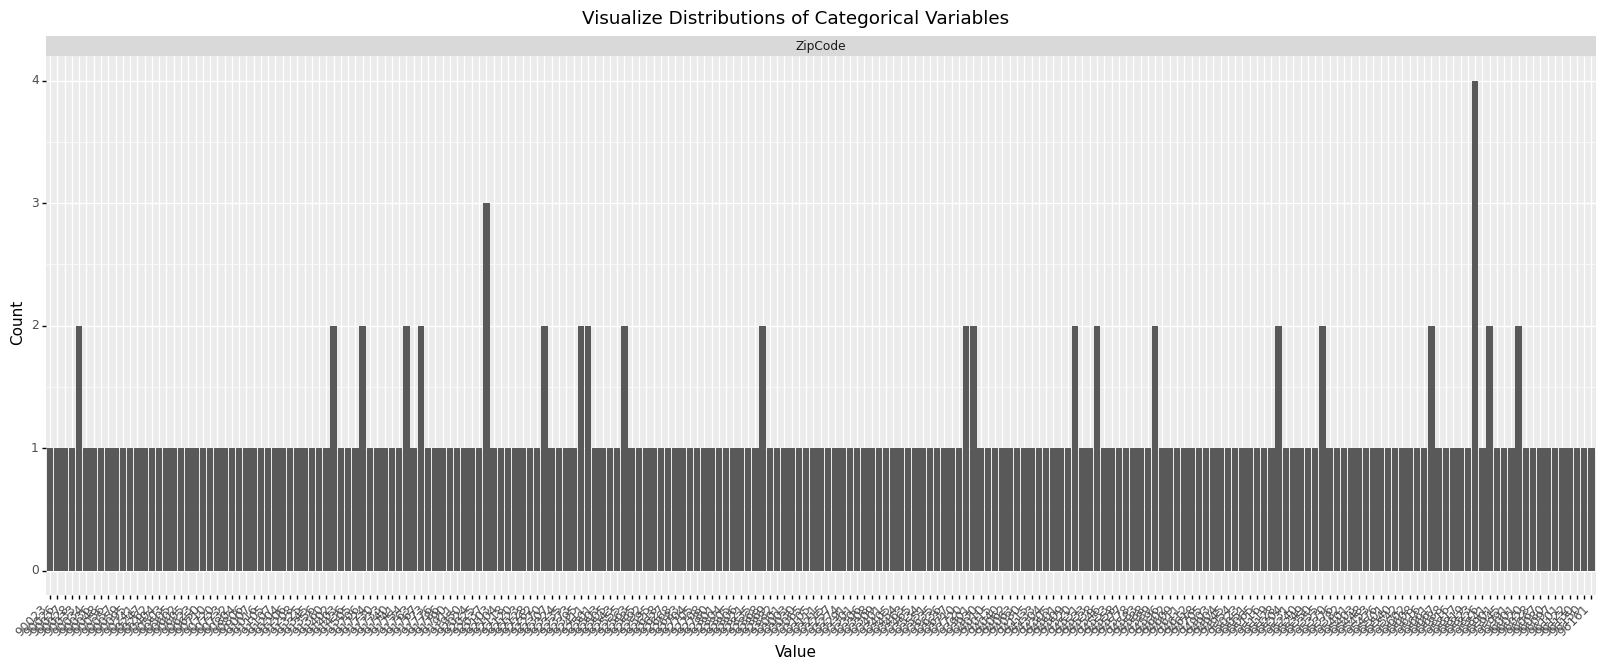

<ggplot: (8787537270408)>

In [11]:
# Now we consider the categorial predictor, Zip Code.

# Identify the categorial variables.
d = train_X.select_dtypes(include = "category").melt()

# Plot the continuous variables.
(
    ggplot(d,aes(x = "value")) +
    geom_bar() +
    facet_wrap("variable", scales = "free") +
    theme(figure_size = (50, 7),
          subplots_adjust = {"wspace" : 0.25, "hspace" : 0.75},
          axis_text_x = element_text(rotation = 45, hjust = 1)) +
    labs(x = "Value", y = "Count", title = "Visualize Distributions of Categorical Variables")
)

In [12]:
# Convert categories to dummies for *ZipCode*.

# Get the dummy variables for *Marital*.
zip_dummies = pd.get_dummies(pricing_data.ZipCode)
# Replace spaces in the dummy column names.
zip_dummies.columns = [c.lower().replace(" ","_") for c in zip_dummies.columns]
# Drop 90015 since we are treating that as our baseline.
zip_dummies = zip_dummies.drop(["90015"], axis = 1) # Baseline
# Concatanate the results to push in to the dummy columns for *ZipCode*.
pricing_data = pd.concat([pricing_data.drop(["ZipCode"], axis = 1), zip_dummies], axis = 1)

In [13]:
# We now drop all the final NAs for all the continuous variables and create a final clean version of our data.
pricing_data_clean = pricing_data.dropna()

In [14]:
# We have made changes from the training data. Re-split using the changed data.

# Identify the hospital's pricing for 70450 as the dependent variable.
y = pricing_data_clean[["HospitalPrice_70450"]]
# Identify the other variables as the independent variables.
X = pricing_data_clean.drop(columns = ["HospitalPrice_70450"])

In [15]:
# (0) Split the data 
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = .25, random_state = 202112)

# (1) Set the folds index to ensure comparable samples
fold_generator = KFold(n_splits = 5, shuffle = True, random_state = 202112)

# (2) Next Let's create our model pipe (note for the model we leave none as a placeholder)
pipe = Pipeline(steps=[("pre_process", pp.MinMaxScaler()), ("model", None)])

# (3) Specify the models and their repsective tuning parameters. 
# Note the naming convention here to reference the model key
search_space = [
    # Linear Model
    {"model" : [LM()]},
    
    # Bagging Decision Tree Classifier 
    {"model": [Bag()]},
    
    # K-nearest Neighbors Classifier
    {"model" : [KNN()],
     "model__n_neighbors" : [5, 10, 25, 50]}, # Tune for different nearest neighbors.
    
    # Decision Tree Classifier
    {"model" : [DT()],
     "model__max_depth" : [2, 3, 4]}, # Tune for different tree depth sizes.
    
    # Random Forest Classifier
    {"model" : [RF()],
     "model__max_depth" : [2, 3, 4], # Tune for different tree depth sizes.
     "model__n_estimators" : [500, 1000, 1500]} # Tune for number of trees/"estimators" grown.
]

# (4) Put it all together in the grid search
search = GridSearchCV(pipe, search_space, 
                      cv = fold_generator,
                      scoring = "neg_mean_squared_error",
                      n_jobs = 4)

# (5) Fit the model to the training data
search.fit(train_X, train_y)

GridSearchCV(cv=KFold(n_splits=5, random_state=202112, shuffle=True),
             estimator=Pipeline(steps=[('pre_process', MinMaxScaler()),
                                       ('model', None)]),
             n_jobs=4,
             param_grid=[{'model': [LinearRegression()]},
                         {'model': [BaggingRegressor()]},
                         {'model': [KNeighborsRegressor(n_neighbors=50)],
                          'model__n_neighbors': [5, 10, 25, 50]},
                         {'model': [DecisionTreeRegressor()],
                          'model__max_depth': [2, 3, 4]},
                         {'model': [RandomForestRegressor()],
                          'model__max_depth': [2, 3, 4],
                          'model__n_estimators': [500, 1000, 1500]}],
             scoring='neg_mean_squared_error')

In [16]:
# Mean out-of-sample (CV) error
search.best_score_

-3268181.3137596464

In [17]:
# We identify the parameters with our best model.
search.best_params_

{'model': KNeighborsRegressor(n_neighbors=50), 'model__n_neighbors': 50}

In [18]:
# Predict() method will use the best model out of the scan.
pred_y = search.predict(test_X)

In [19]:
# Calculate mean squared error.
m.mean_squared_error(test_y, pred_y)

1819483.4699681643

In [20]:
# Calculate the r-squared score for the best model.
m.r2_score(test_y, pred_y)

-0.04126588652525176

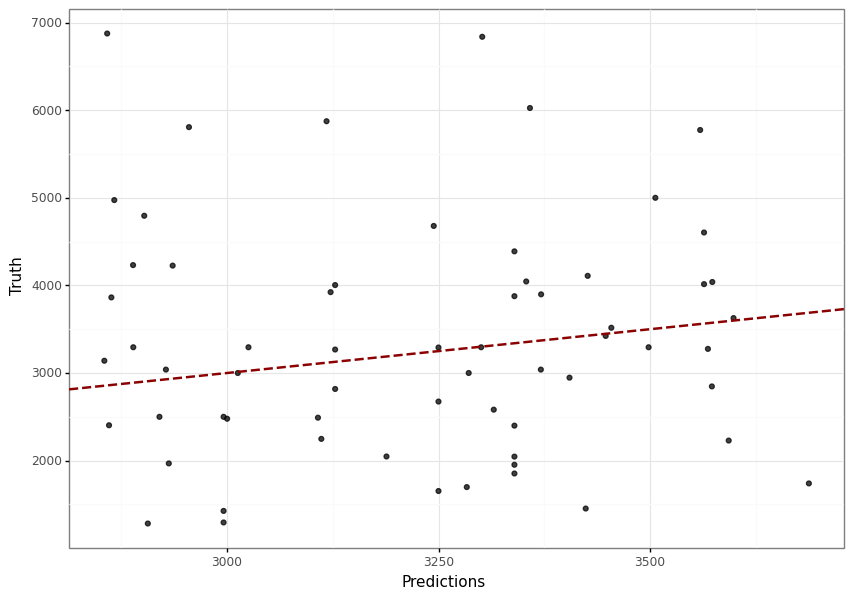

<ggplot: (8787487912982)>

In [21]:
# Create dataframe to hold the predicted y and the test y to compare on a plot.
plot_df = pd.DataFrame({"Predictions" : np.concatenate(pred_y, axis = 0), "Truth" : np.concatenate(test_y.values, axis = 0)})

# Visualize the relationship between the predicted and test y values.
(
    ggplot(plot_df, aes(x = "Predictions", y = "Truth")) +
    geom_point(alpha = .75) +
    geom_abline(linetype = "dashed", color = "darkred", size = 1) +
    theme_bw() +
    theme(figure_size = (10, 7))
)